# Hệ Thống Gợi Ý Sản Phẩm Thương Mại Điện Tử Sử Dụng Lọc Cộng Tác Dựa Trên Mô Hình (Model-based Collaborative Filtering) và Phân Tích Kỹ Thuật Phân Tích Ma Trận SVD

## 1. Giới thiệu (Introduction)

Hệ thống gợi ý (Recommender Systems) đóng vai trò then chốt trong sự phát triển của các doanh nghiệp thương mại điện tử hiện nay. Bằng cách phân tích hành vi và sở thích của khách hàng, hệ thống gợi ý giúp cá nhân hóa trải nghiệm người dùng, đề xuất các sản phẩm phù hợp, nâng cao tỷ lệ chuyển đổi và tăng doanh thu.

Dự án nghiên cứu này tập trung nghiên cứu và xây dựng một phương pháp gợi ý sản phẩm bài bản dựa trên kỹ thuật **Lọc cộng tác dựa trên mô hình (Model-based Collaborative Filtering)**, cụ thể là thuật toán **Phân tách ma trận SVD (Singular Value Decomposition)**. 

### Phân loại bài toán trong Machine Learning

Bài toán chính của dự án là **Regression (Hồi quy)**.

Lý do là mục tiêu cốt lõi của mô hình là **dự đoán giá trị Rating** mà một người dùng có thể dành cho một sản phẩm chưa từng đánh giá. Rating là một biến số định lượng, có giá trị trên thang điểm từ 1.0 đến 5.0, nên đầu ra của mô hình là một giá trị số. Cụ thể, từ dữ liệu lịch sử gồm `UserId`, `ProductId` và `Rating`, mô hình học mối quan hệ tiềm ẩn giữa người dùng và sản phẩm, sau đó ước lượng các rating còn thiếu trong ma trận User-Item.

Dự án không thuộc **Classification**, vì mô hình không dự đoán một nhãn rời rạc như "mua/không mua" hay "thích/không thích". Dự án cũng không thuộc **Clustering**, vì mục tiêu chính không phải chia người dùng hoặc sản phẩm thành các cụm. Các kỹ thuật trực quan hóa như PCA hoặc t-SNE chỉ được dùng để phân tích không gian đặc trưng ẩn sau khi huấn luyện, không phải nhiệm vụ học máy chính.

Vì vậy, có thể mô tả bài toán chính như sau: **dự đoán Rating theo hướng hồi quy, sau đó sử dụng các rating dự đoán để xếp hạng và gợi ý Top-N sản phẩm cho từng người dùng**.

```text
Dữ liệu Rating Người dùng - Sản phẩm
      ↓
Phân tách ma trận SVD / Matrix Factorization
      ↓
Dự đoán các rating chưa biết
      ↓
Trích xuất danh sách Top-N gợi ý cho từng người dùng
```

Đánh giá hiệu năng của mô hình vì thế bao gồm hai nhóm chỉ số. Thứ nhất là các độ đo hồi quy như **RMSE** và **MAE** để đo sai số giữa rating dự đoán và rating thực tế. Thứ hai là các độ đo gợi ý/xếp hạng như **Precision@K**, **Recall@K**, và **NDCG@K** để đánh giá chất lượng danh sách Top-N sản phẩm được đề xuất thực tế.

## 2. Định nghĩa Bài toán (Problem Definition)

Cho tập hợp người dùng $U = \{u_1, u_2, ..., u_m\}$ và tập hợp sản phẩm $I = \{i_1, i_2, ..., i_n\}$. Dữ liệu lịch sử được biểu diễn dưới dạng ma trận Rating $R \in \mathbb{R}^{m \times n}$, trong đó mỗi phần tử $r_{u,i}$ biểu diễn điểm đánh giá của người dùng $u$ cho sản phẩm $i$ (thường là thang điểm từ 1 đến 5). Do mỗi người dùng chỉ tương tác với một lượng rất nhỏ sản phẩm, ma trận $R$ chứa phần lớn các giá trị bị khuyết (NaN).

Mục tiêu của Matrix Factorization là xấp xỉ ma trận $R$ bằng tích của hai ma trận ẩn có số chiều thấp hơn:
$$R \approx P \times Q^T$$
Trong đó:
- $P \in \mathbb{R}^{m \times k}$ đại diện cho không gian đặc trưng ẩn (latent features) của người dùng. Mỗi dòng $p_u$ là một vector biểu diễn sở thích ẩn của người dùng $u$ với $k$ chiều đặc trưng ẩn.
- $Q \in \mathbb{R}^{n \times k}$ đại diện cho không gian đặc trưng ẩn của sản phẩm. Mỗi dòng $q_i$ là một vector biểu diễn thuộc tính ẩn của sản phẩm $i$.
- $k \ll \min(m, n)$ là số lượng nhân tố ẩn (latent factors).

Giá trị rating dự đoán $\hat{r}_{u,i}$ được tính bằng tích vô hướng của hai vector đặc trưng tương ứng:
$$\hat{r}_{u,i} = p_u \cdot q_i^T = \sum_{f=1}^{k} p_{u,f} q_{i,f}$$

Nếu áp dụng chuẩn hóa (mean-centering) theo người dùng, công thức dự đoán sẽ là:
$$\hat{r}_{u,i} = \mu_u + p_u \cdot q_i^T$$
Trong đó $\mu_u$ là rating trung bình của người dùng $u$ trên các sản phẩm họ đã đánh giá.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use("ggplot")
np.random.seed(42)

## 3. Tải Bộ Dữ Liệu (Dataset Loading)

Dữ liệu được sử dụng là bộ dữ liệu đánh giá sản phẩm làm đẹp của Amazon (**Amazon Beauty Ratings**), lưu trữ trong file `ratings_Beauty.csv`. 
Các trường thông tin chính bao gồm:
- `UserId`: Định danh duy nhất của người dùng.
- `ProductId`: Định danh duy nhất của sản phẩm.
- `Rating`: Điểm số đánh giá từ 1.0 đến 5.0.
- `Timestamp`: Thời gian thực hiện đánh giá dưới dạng Unix epoch.

In [11]:
# Kiểm tra và thiết lập đường dẫn file dữ liệu phù hợp
csv_path = 'input/amazon-ratings/ratings_Beauty.csv'
if not os.path.exists(csv_path):
    csv_path = '../input/amazon-ratings/ratings_Beauty.csv'

print(f"Đang tải dữ liệu từ: {csv_path}")
amazon_ratings = pd.read_csv(csv_path)

# Kiểm tra thông tin kích thước và cấu trúc dữ liệu
print(f"Kích thước dữ liệu gốc: {amazon_ratings.shape}")
print("5 dòng dữ liệu đầu tiên:")
display(amazon_ratings.head())

# Kiểm tra và xử lý giá trị khuyết thiếu (missing values)
missing_values = amazon_ratings.isnull().sum()
print("\nSố lượng giá trị khuyết thiếu trên từng cột:")
print(missing_values)

# Loại bỏ các giá trị khuyết thiếu nếu có
amazon_ratings = amazon_ratings.dropna()

# Kiểm tra các dòng trùng lặp (duplicate rows)
duplicates = amazon_ratings.duplicated(subset=['UserId', 'ProductId']).sum()
print(f"\nSố lượng đánh giá trùng lặp (UserId + ProductId): {duplicates}")

# Ép kiểu dữ liệu phù hợp để tối ưu bộ nhớ
amazon_ratings['UserId'] = amazon_ratings['UserId'].astype(str)
amazon_ratings['ProductId'] = amazon_ratings['ProductId'].astype(str)
amazon_ratings['Rating'] = amazon_ratings['Rating'].astype(float)
if 'Timestamp' in amazon_ratings.columns:
    amazon_ratings['Timestamp'] = pd.to_datetime(amazon_ratings['Timestamp'], unit='s', errors='coerce')

Đang tải dữ liệu từ: input/amazon-ratings/ratings_Beauty.csv
Kích thước dữ liệu gốc: (2023070, 4)
5 dòng dữ liệu đầu tiên:


,UserId,ProductId,Rating,Timestamp
0,A39HTATAQ9V7YF,0205616461,5.0,1369699200
1,A3JM6GV9MNOF9X,0558925278,3.0,1355443200
2,A1Z513UWSAAO0F,0558925278,5.0,1404691200
3,A1WMRR494NWEWV,0733001998,4.0,1382572800
4,A3IAAVS479H7M7,0737104473,1.0,1274227200



Số lượng giá trị khuyết thiếu trên từng cột:
UserId       0
ProductId    0
Rating       0
Timestamp    0
dtype: int64

Số lượng đánh giá trùng lặp (UserId + ProductId): 0


## 4. Phân Tích Khám Phá Dữ Liệu - EDA (Exploratory Data Analysis)

Trước khi xây dựng mô hình, ta thực hiện phân tích thống kê để hiểu rõ đặc trưng của tập dữ liệu rating này.

In [12]:
num_users = amazon_ratings['UserId'].nunique()
num_products = amazon_ratings['ProductId'].nunique()
num_ratings = len(amazon_ratings)
mean_rating = amazon_ratings['Rating'].mean()
min_rating = amazon_ratings['Rating'].min()
max_rating = amazon_ratings['Rating'].max()

print("--- THỐNG KÊ TỔNG QUAN DỮ LIỆU ---")
print(f"Số lượng người dùng (Users): {num_users:,}")
print(f"Số lượng sản phẩm (Products): {num_products:,}")
print(f"Tổng số lượt đánh giá (Ratings): {num_ratings:,}")
print(f"Điểm đánh giá trung bình: {mean_rating:.2f}")
print(f"Điểm đánh giá nhỏ nhất: {min_rating}")
print(f"Điểm đánh giá lớn nhất: {max_rating}")

--- THỐNG KÊ TỔNG QUAN DỮ LIỆU ---
Số lượng người dùng (Users): 1,210,271
Số lượng sản phẩm (Products): 249,274
Tổng số lượt đánh giá (Ratings): 2,023,070
Điểm đánh giá trung bình: 4.15
Điểm đánh giá nhỏ nhất: 1.0
Điểm đánh giá lớn nhất: 5.0


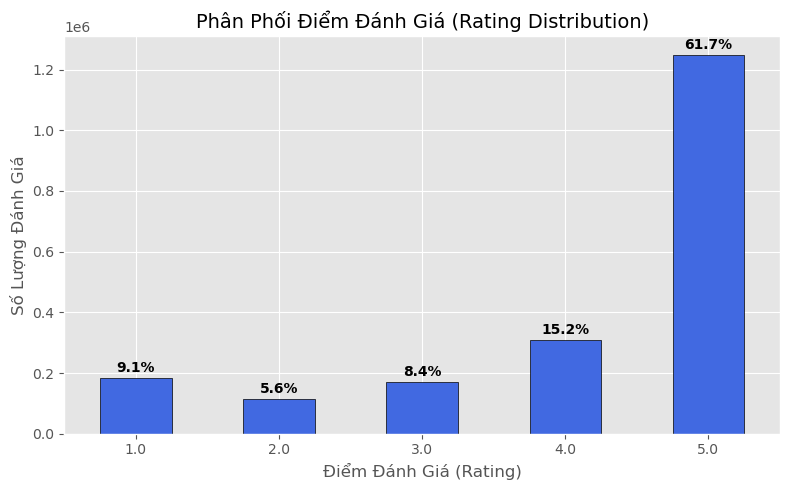

Nhận xét: Phần lớn các đánh giá tập trung vào điểm 5.0 (hơn 50%), cho thấy người dùng có xu hướng đánh giá tích cực hoặc chỉ đánh giá khi họ hài lòng với sản phẩm. Phân phối này bị lệch nghiêm trọng về phía điểm số cao, đây là đặc trưng thường gặp trong các bộ dữ liệu thương mại điện tử.


In [13]:
# Vẽ biểu đồ phân phối điểm đánh giá
rating_counts = amazon_ratings['Rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
rating_counts.plot(kind='bar', color='royalblue', edgecolor='black')
plt.title('Phân Phối Điểm Đánh Giá (Rating Distribution)', fontsize=14)
plt.xlabel('Điểm Đánh Giá (Rating)', fontsize=12)
plt.ylabel('Số Lượng Đánh Giá', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(rating_counts.values):
    plt.text(i, v + 20000, f"{v/num_ratings*100:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Nhận xét: Phần lớn các đánh giá tập trung vào điểm 5.0 (hơn 50%), cho thấy người dùng có xu hướng đánh giá tích cực hoặc chỉ đánh giá khi họ hài lòng với sản phẩm. Phân phối này bị lệch nghiêm trọng về phía điểm số cao, đây là đặc trưng thường gặp trong các bộ dữ liệu thương mại điện tử.")

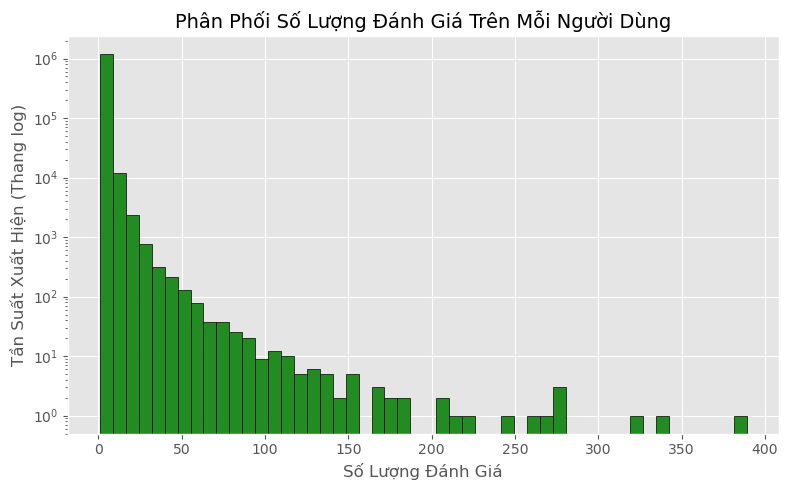

Số lượng đánh giá tối đa của một user: 389
Tỷ lệ user chỉ đánh giá duy nhất 1 sản phẩm: 73.32%
Nhận xét: Hơn 80% người dùng chỉ đánh giá 1 sản phẩm duy nhất. Điều này cho thấy dữ liệu cực kỳ thưa thớt ở mức người dùng đơn lẻ, gây khó khăn cho việc huấn luyện mô hình học máy nếu không lọc bỏ các user quá ít tương tác.


In [14]:
# Tính số lượng rating trên mỗi user
user_rating_counts = amazon_ratings['UserId'].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(user_rating_counts, bins=50, log=True, color='forestgreen', edgecolor='black')
plt.title('Phân Phối Số Lượng Đánh Giá Trên Mỗi Người Dùng', fontsize=14)
plt.xlabel('Số Lượng Đánh Giá', fontsize=12)
plt.ylabel('Tần Suất Xuất Hiện (Thang log)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Số lượng đánh giá tối đa của một user: {user_rating_counts.max()}")
print(f"Tỷ lệ user chỉ đánh giá duy nhất 1 sản phẩm: {(user_rating_counts == 1).sum() / num_users * 100:.2f}%")
print("Nhận xét: Hơn 80% người dùng chỉ đánh giá 1 sản phẩm duy nhất. Điều này cho thấy dữ liệu cực kỳ thưa thớt ở mức người dùng đơn lẻ, gây khó khăn cho việc huấn luyện mô hình học máy nếu không lọc bỏ các user quá ít tương tác.")

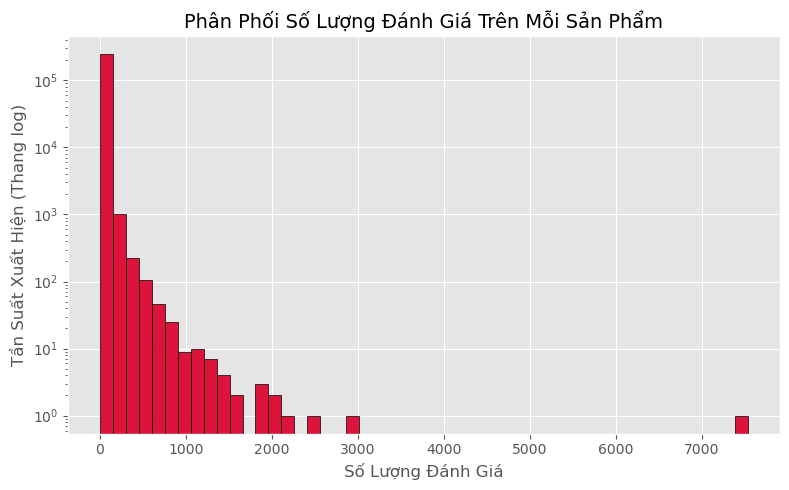

Số lượng đánh giá tối đa của một sản phẩm: 7533
Tỷ lệ sản phẩm chỉ được đánh giá đúng 1 lần: 41.51%
Nhận xét: Phân phối số lượng đánh giá trên sản phẩm tuân theo phân phối đuôi dài (long-tail distribution). Có rất ít sản phẩm cực kỳ phổ biến được đánh giá hàng nghìn lần, trong khi phần lớn sản phẩm chỉ có 1 hoặc vài đánh giá.


In [15]:
# Tính số lượng rating trên mỗi product
product_rating_counts = amazon_ratings['ProductId'].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(product_rating_counts, bins=50, log=True, color='crimson', edgecolor='black')
plt.title('Phân Phối Số Lượng Đánh Giá Trên Mỗi Sản Phẩm', fontsize=14)
plt.xlabel('Số Lượng Đánh Giá', fontsize=12)
plt.ylabel('Tần Suất Xuất Hiện (Thang log)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Số lượng đánh giá tối đa của một sản phẩm: {product_rating_counts.max()}")
print(f"Tỷ lệ sản phẩm chỉ được đánh giá đúng 1 lần: {(product_rating_counts == 1).sum() / num_products * 100:.2f}%")
print("Nhận xét: Phân phối số lượng đánh giá trên sản phẩm tuân theo phân phối đuôi dài (long-tail distribution). Có rất ít sản phẩm cực kỳ phổ biến được đánh giá hàng nghìn lần, trong khi phần lớn sản phẩm chỉ có 1 hoặc vài đánh giá.")

In [16]:
# Tính độ thưa (Sparsity) của ma trận User-Item gốc
sparsity = 1.0 - (num_ratings / (num_users * num_products))
print(f"Độ thưa (Sparsity) của ma trận User-Item gốc: {sparsity * 100:.6f}%")

print("\nGiải thích ý nghĩa:")
print("Sparsity gần 99.999% nghĩa là hầu hết tất cả người dùng chưa từng tương tác hay đánh giá các sản phẩm trong hệ thống.")
print("Đây chính là đặc trưng cốt lõi của các bài toán Recommender Systems và là nguyên nhân chính đòi hỏi phải áp dụng các kỹ thuật Matrix Factorization hoặc SVD để giảm chiều và suy diễn ra các giá trị rating chưa biết từ không gian nhân tố ẩn.")

Độ thưa (Sparsity) của ma trận User-Item gốc: 99.999329%

Giải thích ý nghĩa:
Sparsity gần 99.999% nghĩa là hầu hết tất cả người dùng chưa từng tương tác hay đánh giá các sản phẩm trong hệ thống.
Đây chính là đặc trưng cốt lõi của các bài toán Recommender Systems và là nguyên nhân chính đòi hỏi phải áp dụng các kỹ thuật Matrix Factorization hoặc SVD để giảm chiều và suy diễn ra các giá trị rating chưa biết từ không gian nhân tố ẩn.


## 5. Tiền Xử Lý Dữ Liệu (Data Preprocessing)

Do kích thước dữ liệu gốc rất lớn (~2 triệu ratings) và cực kỳ thưa, ta cần thực hiện tiền xử lý dữ liệu:
1. **Loại bỏ đánh giá trùng lặp:** Nếu người dùng đánh giá cùng một sản phẩm nhiều lần, ta lấy điểm đánh giá trung bình.
2. **Lọc dữ liệu thưa (Filter sparse users/products):** 
   - Chỉ giữ lại những người dùng đã đánh giá ít nhất `MIN_USER_RATINGS = 5` sản phẩm.
   - Chỉ giữ lại những sản phẩm được đánh giá ít nhất `MIN_PRODUCT_RATINGS = 5` lần.
3. **Giới hạn kích thước mẫu (Sub-sampling):** Để đảm bảo notebook có thể chạy ổn định, nhanh chóng và không tràn bộ nhớ trên máy tính thông thường, ta lấy một phân mẫu gồm `MAX_USERS = 5000` người dùng năng nổ nhất và `MAX_PRODUCTS = 5000` sản phẩm được đánh giá nhiều nhất trong nhóm dữ liệu đã lọc.

In [17]:
MIN_USER_RATINGS = 5
MIN_PRODUCT_RATINGS = 5
MAX_USERS = 5000
MAX_PRODUCTS = 5000

# 1. Loại bỏ các đánh giá trùng lặp bằng cách tính trung bình cộng
ratings_cleaned = amazon_ratings.groupby(['UserId', 'ProductId'], as_index=False)['Rating'].mean()
print(f"Kích thước sau khi làm sạch trùng lặp: {ratings_cleaned.shape}")

# 2. Lọc các user có ít nhất 5 ratings và product có ít nhất 5 ratings
user_counts = ratings_cleaned['UserId'].value_counts()
ratings_filtered = ratings_cleaned[ratings_cleaned['UserId'].isin(user_counts[user_counts >= MIN_USER_RATINGS].index)]

product_counts = ratings_filtered['ProductId'].value_counts()
ratings_filtered_both = ratings_filtered[ratings_filtered['ProductId'].isin(product_counts[product_counts >= MIN_PRODUCT_RATINGS].index)]

print(f"Kích thước sau khi lọc người dùng (>= {MIN_USER_RATINGS}) và sản phẩm (>= {MIN_PRODUCT_RATINGS}): {ratings_filtered_both.shape}")
print(f"Số lượng user sau khi lọc: {ratings_filtered_both['UserId'].nunique()}")
print(f"Số lượng product sau khi lọc: {ratings_filtered_both['ProductId'].nunique()}")

# 3. Sub-sampling các user và product năng nổ nhất để tránh tràn bộ nhớ khi tính toán ma trận dày đặc
top_users = ratings_filtered_both['UserId'].value_counts().head(MAX_USERS).index
df_sub = ratings_filtered_both[ratings_filtered_both['UserId'].isin(top_users)]

top_products = df_sub['ProductId'].value_counts().head(MAX_PRODUCTS).index
df_sub = df_sub[df_sub['ProductId'].isin(top_products)].reset_index(drop=True)

print(f"\nKích thước sau khi phân mẫu tối đa (Max {MAX_USERS} Users x {MAX_PRODUCTS} Products): {df_sub.shape}")
print(f"Số lượng user trong phân mẫu: {df_sub['UserId'].nunique()}")
print(f"Số lượng product trong phân mẫu: {df_sub['ProductId'].nunique()}")
print(f"Độ thưa của phân mẫu: {(1.0 - len(df_sub) / (df_sub['UserId'].nunique() * df_sub['ProductId'].nunique())) * 100:.2f}%")

Kích thước sau khi làm sạch trùng lặp: (2023070, 3)
Kích thước sau khi lọc người dùng (>= 5) và sản phẩm (>= 5): (313823, 3)
Số lượng user sau khi lọc: 51369
Số lượng product sau khi lọc: 19369

Kích thước sau khi phân mẫu tối đa (Max 5000 Users x 5000 Products): (73221, 3)
Số lượng user trong phân mẫu: 4999
Số lượng product trong phân mẫu: 5000
Độ thưa của phân mẫu: 99.71%


## 6. Chia Tập Huấn Luyện và Tập Kiểm Thử (Train/Test Split)

Trong hệ thống gợi ý, việc chia tập dữ liệu huấn luyện và kiểm thử một cách ngẫu nhiên trên toàn bộ dòng dữ liệu (như cách chia thông thường) sẽ dẫn đến lỗi logic **Cold-start**. Cụ thể, một số người dùng có thể chỉ xuất hiện trong tập kiểm thử (test set) mà không hề có lịch sử đánh giá nào trong tập huấn luyện (train set). Điều này khiến mô hình không thể học được latent vector tương ứng của họ, dẫn tới không thể đưa ra dự đoán thực tế.

Do đó, chúng ta thiết kế một hàm phân chia **Train/Test Split theo từng người dùng (User-based Split)**:
- Với mỗi người dùng, ta lấy ngẫu nhiên **80%** số lượt đánh giá đưa vào tập huấn luyện (Train set) và **20%** đưa vào tập kiểm thử (Test set).
- Điều này đảm bảo rằng mỗi người dùng xuất hiện ở tập kiểm thử đều đã xuất hiện và có lịch sử tối thiểu trong tập huấn luyện để mô hình học tập.

In [18]:
def train_test_split_by_user(df, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    train_indices = []
    test_indices = []
    
    # Nhóm theo người dùng
    grouped = df.groupby('UserId')
    for user_id, group in grouped:
        indices = group.index.values
        n = len(indices)
        
        if n >= 5:
            # Trộn ngẫu nhiên các chỉ số đánh giá của người dùng hiện tại
            shuffled = np.random.permutation(indices)
            n_test = int(np.ceil(n * test_size))
            
            # Đảm bảo giữ ít nhất 1 rating trong tập train và tập test
            if n_test >= n:
                n_test = n - 1
            if n_test <= 0:
                n_test = 1
                
            test_idx = shuffled[:n_test]
            train_idx = shuffled[n_test:]
            
            test_indices.extend(test_idx)
            train_indices.extend(train_idx)
        else:
            # Nếu số lượng đánh giá quá ít, đưa toàn bộ vào tập train
            train_indices.extend(indices)
            
    train_df = df.loc[train_indices].copy()
    test_df = df.loc[test_indices].copy()
    return train_df, test_df

train_df, test_df = train_test_split_by_user(df_sub)

print("--- THÔNG TIN PHÂN CHIA TRAIN/TEST ---")
print(f"Số lượng bản ghi tập huấn luyện (Train size): {train_df.shape[0]}")
print(f"Số lượng bản ghi tập kiểm thử (Test size): {test_df.shape[0]}")
print(f"Số lượng users trong train: {train_df['UserId'].nunique()}")
print(f"Số lượng users trong test: {test_df['UserId'].nunique()}")
print(f"Số lượng products trong train: {train_df['ProductId'].nunique()}")
print(f"Số lượng products trong test: {test_df['ProductId'].nunique()}")

# Kiểm tra xem có user nào trong test không xuất hiện trong train không
cold_users = set(test_df['UserId']) - set(train_df['UserId'])
print(f"Số lượng user bị cold-start trong tập test: {len(cold_users)}")

--- THÔNG TIN PHÂN CHIA TRAIN/TEST ---
Số lượng bản ghi tập huấn luyện (Train size): 56753
Số lượng bản ghi tập kiểm thử (Test size): 16468
Số lượng users trong train: 4999
Số lượng users trong test: 4823
Số lượng products trong train: 4999
Số lượng products trong test: 4307
Số lượng user bị cold-start trong tập test: 0


## 7. Xây Dựng Ma Trận User-Item và Chuẩn Hóa Điểm (User-Item Matrix Construction)

Từ dữ liệu dạng bảng (tabular) của tập huấn luyện, ta chuyển đổi thành dạng ma trận hai chiều (User-Item Matrix):
- Dòng: Các UserId đại diện cho người dùng.
- Cột: Các ProductId đại diện cho sản phẩm.
- Giá trị: Rating tương ứng từ 1.0 đến 5.0.

### Xử lý các ô trống trong ma trận

Các ô trống đại diện cho các sản phẩm người dùng chưa đánh giá. Trong mô hình Phân tách ma trận SVD truyền thống của thư viện `scikit-learn` (được thiết kế cho ma trận dày đặc), ta cần xử lý các ô trống này. Điền giá trị `0` trực tiếp là một phương án đơn giản nhưng không tối ưu vì điểm `0` nằm ngoài thang đo 1-5 và mang hàm ý người dùng cực kỳ ghét sản phẩm.

Phương pháp chuẩn hơn là **Chuẩn hóa điểm đánh giá theo dòng (User Mean-Centering)**:
1. Tính điểm đánh giá trung bình của mỗi người dùng $\mu_u$.
2. Trừ điểm đánh giá thực tế cho trung bình này: $r^{centered}_{u,i} = r_{u,i} - \mu_u$.
3. Điền giá trị `0` cho các ô trống trên ma trận đã trừ trung bình này. Điểm `0` lúc này có ý nghĩa tương đương với điểm đánh giá trung bình của người dùng đó (trạng thái trung lập).

In [19]:
# Xây dựng ma trận User-Item từ tập huấn luyện
user_item_matrix = train_df.pivot_table(index='UserId', columns='ProductId', values='Rating')
print(f"Kích thước ma trận User-Item: {user_item_matrix.shape}")

# Thực hiện Mean-Centering theo từng người dùng
user_means = user_item_matrix.mean(axis=1)
matrix_centered = user_item_matrix.sub(user_means, axis=0).fillna(0)

print("5 dòng đầu của ma trận User-Item sau khi chuẩn hóa (Mean-Centered):")
display(matrix_centered.head())

KeyboardInterrupt: 

## 8. Lọc Cộng Tác Dựa Trên Mô Hình Sử Dụng SVD (Model-based Collaborative Filtering using SVD)

Ta huấn luyện mô hình SVD trên ma trận `matrix_centered` đã được chuẩn hóa. Thuật toán phân tách ma trận thực hiện xấp xỉ ma trận bằng cách tìm ra các hướng đặc trưng quan trọng nhất thông qua thuật toán Phân tách trị riêng (Truncated SVD).

Các tham số huấn luyện chính:
- `n_components`: Số lượng latent factors (nhân tố ẩn) $k$. Đây là siêu tham số quan trọng nhất của mô hình. Khi $k$ tăng, mô hình học được nhiều đặc trưng tinh vi hơn nhưng cũng dễ bị quá khớp (overfitting) và tốn tài nguyên tính toán hơn.
- `random_state`: Đảm bảo tính lặp lại của kết quả phân tách.

In [ ]:
# Huấn luyện mô hình TruncatedSVD với một số latent factors mặc định k = 20
k_default = 20
svd = TruncatedSVD(n_components=k_default, random_state=42)

t0 = time.time()
user_factors = svd.fit_transform(matrix_centered)
item_factors = svd.components_
train_time = time.time() - t0

print(f"Thời gian huấn luyện SVD (k={k_default}): {train_time:.4f} giây")
print(f"Kích thước ma trận latent của người dùng (User Factors): {user_factors.shape}")
print(f"Kích thước ma trận latent của sản phẩm (Item Factors): {item_factors.shape}")
print(f"Tổng tỷ lệ phương sai được giải thích (Explained Variance Ratio): {svd.explained_variance_ratio_.sum() * 100:.2f}%")

## 9. Dự Đoán Điểm Đánh Giá (Rating Prediction)

Ta thực hiện tái cấu trúc lại ma trận điểm dự đoán bằng cách nhân ma trận nhân tố ẩn của người dùng và sản phẩm, sau đó cộng lại giá trị trung bình $\mu_u$ đã trừ ban đầu:
$$\hat{R} = (U \Sigma) \times V^T + \mu_u = P \times Q^T + \mu_u$$
Đồng thời, ta giới hạn (clip) các giá trị dự đoán về đúng khoảng điểm thực tế `[1.0, 5.0]` để đảm bảo tính hợp lệ.

In [ ]:
# Tái cấu trúc ma trận rating dự đoán
pred_centered = np.dot(user_factors, item_factors)
pred_ratings = pred_centered + user_means.values.reshape(-1, 1)
pred_ratings = np.clip(pred_ratings, 1.0, 5.0)

# Chuyển đổi về DataFrame để tra cứu dễ dàng
pred_df = pd.DataFrame(pred_ratings, index=user_item_matrix.index, columns=user_item_matrix.columns)

# Hàm tra cứu rating dự đoán cho một cặp User - Product cụ thể
def predict_rating(user_id, product_id, pred_df):
    if user_id in pred_df.index and product_id in pred_df.columns:
        predicted_val = pred_df.at[user_id, product_id]
        return predicted_val
    else:
        # Trường hợp người dùng hoặc sản phẩm chưa từng xuất hiện trong tập huấn luyện (Cold-start)
        return "Cold-start: Không thể dự đoán điểm số vì User hoặc Product chưa xuất hiện trong tập huấn luyện."

# Chạy thử nghiệm dự đoán
sample_user = train_df['UserId'].iloc[0]
sample_product = train_df['ProductId'].iloc[0]
predicted = predict_rating(sample_user, sample_product, pred_df)
actual = train_df[(train_df['UserId'] == sample_user) & (train_df['ProductId'] == sample_product)]['Rating'].values[0]

print(f"Cặp User - Product mẫu: ({sample_user} - {sample_product})")
print(f"Điểm đánh giá thực tế (Actual Rating): {actual}")
print(f"Điểm đánh giá dự đoán (Predicted Rating): {predicted:.4f}")

# Thử nghiệm trường hợp Cold-start
print(f"Dự đoán cho user lạ 'USER_FAKE_999': {predict_rating('USER_FAKE_999', sample_product, pred_df)}")

## 10. Đề Xuất Top-N Sản Phẩm (Top-N Recommendation)

Khi đưa vào hoạt động thực tế, mục tiêu của hệ thống là tạo ra danh sách đề xuất các sản phẩm mới cho người dùng. 
Quy trình thực hiện hàm `recommend_products`:
1. Lấy danh sách toàn bộ các sản phẩm mà người dùng đã đánh giá trong quá khứ (từ tập huấn luyện).
2. Loại bỏ các sản phẩm đã đánh giá này ra khỏi danh sách đề cử (tránh đề xuất lại sản phẩm cũ).
3. Lấy điểm dự đoán của người dùng đó cho tất cả các sản phẩm còn lại.
4. Sắp xếp điểm số dự đoán theo thứ tự giảm dần và lấy ra Top-N sản phẩm đứng đầu.

In [ ]:
def recommend_products(user_id, user_item_matrix, pred_df, top_n=10):
    if user_id not in pred_df.index:
        return f"Lỗi: User {user_id} không có dữ liệu huấn luyện (Cold-start)."
    
    # Lấy thông tin các sản phẩm user đã tương tác trong train
    user_history = user_item_matrix.loc[user_id]
    rated_items = user_history[user_history.notna()].index
    
    # Lấy toàn bộ rating dự đoán của user hiện tại
    user_predictions = pred_df.loc[user_id]
    
    # Loại bỏ các sản phẩm đã tương tác
    recommendations = user_predictions.drop(rated_items, errors='ignore')
    
    # Sắp xếp và lấy Top-N
    top_recommendations = recommendations.sort_values(ascending=False).head(top_n)
    
    # Chuyển đổi thành DataFrame kết quả đẹp mắt
    recommendations_df = pd.DataFrame({
        'ProductId': top_recommendations.index,
        'PredictedRating': top_recommendations.values
    }).reset_index(drop=True)
    
    return recommendations_df

# Chạy thử nghiệm gợi ý Top-10 sản phẩm cho một user ngẫu nhiên
random_user_id = train_df['UserId'].iloc[15]
print(f"\nDanh sách Top-10 sản phẩm gợi ý cho User: {random_user_id}")
recommendations_result = recommend_products(random_user_id, user_item_matrix, pred_df, top_n=10)
display(recommendations_result)

## 11. Các Chỉ Số Đánh Giá (Evaluation Metrics)

Để đánh giá toàn diện mô hình, ta lập trình các hàm tính toán 5 chỉ số đo lường:

### 11.1 RMSE (Root Mean Squared Error)
Đo lường sai số dự đoán điểm đánh giá. Phạt nặng các sai số lớn:
$$RMSE = \sqrt{\frac{1}{|T|} \sum_{(u,i) \in T} (r_{u,i} - \hat{r}_{u,i})^2}$$
Trong đó $T$ là tập kiểm thử (Test set).

### 11.2 MAE (Mean Absolute Error)
Đo lường sai số dự đoán tuyệt đối trung bình, ít bị ảnh hưởng bởi nhiễu hơn RMSE:
$$MAE = \frac{1}{|T|} \sum_{(u,i) \in T} |r_{u,i} - \hat{r}_{u,i}|$$

### 11.3 Precision@K
Đo lường tỷ lệ các sản phẩm được đề xuất thực sự hữu ích. Định nghĩa sản phẩm hữu ích (relevant item) là sản phẩm có điểm đánh giá thực tế từ người dùng lớn hơn hoặc bằng ngưỡng (`threshold = 4.0`):
$$Precision@K = \frac{\text{Số lượng sản phẩm đề xuất trúng đích} \cap \text{Sản phẩm thực sự thích}}{K}$$

### 11.4 Recall@K
Đo lường tỷ lệ phủ của các sản phẩm đề xuất so với toàn bộ sản phẩm thực sự thích của người dùng trong tập test:
$$Recall@K = \frac{\text{Số lượng sản phẩm đề xuất trúng đích} \cap \text{Sản phẩm thực sự thích}}{\text{Tổng số sản phẩm người dùng thực sự thích trong tập test}}$$

### 11.5 NDCG@K (Normalized Discounted Cumulative Gain)
Đo lường chất lượng xếp hạng của danh sách gợi ý. Điểm của sản phẩm được cộng dựa trên vị trí xếp hạng của nó trong danh sách (sản phẩm đúng xếp ở vị trí đầu tiên sẽ mang lại nhiều điểm hơn so với xếp ở vị trí cuối):
$$DCG@K = \sum_{i=1}^{K} \frac{2^{rel_i} - 1}{\log_2(i + 1)}$$
$$IDCG@K = \sum_{i=1}^{\min(K, |\text{Relevant Items}|)} \frac{1}{\log_2(i + 1)}$$
$$NDCG@K = \frac{DCG@K}{IDCG@K}$$
Trong đó $rel_i = 1$ nếu sản phẩm thứ $i$ được gợi ý có trong tập relevant test, ngược lại bằng 0.

In [ ]:
def rmse_score(test_df, pred_df):
    actual = []
    predicted = []
    skipped = 0
    for idx, row in test_df.iterrows():
        u = row['UserId']
        p = row['ProductId']
        r = row['Rating']
        if u in pred_df.index and p in pred_df.columns:
            actual.append(r)
            predicted.append(pred_df.at[u, p])
        else:
            skipped += 1
    if not actual:
        return 0.0, skipped
    return np.sqrt(mean_squared_error(actual, predicted)), skipped

def mae_score(test_df, pred_df):
    actual = []
    predicted = []
    skipped = 0
    for idx, row in test_df.iterrows():
        u = row['UserId']
        p = row['ProductId']
        r = row['Rating']
        if u in pred_df.index and p in pred_df.columns:
            actual.append(r)
            predicted.append(pred_df.at[u, p])
        else:
            skipped += 1
    if not actual:
        return 0.0, skipped
    return mean_absolute_error(actual, predicted), skipped

def precision_recall_ndcg_at_k_fast(test_df, train_df, pred_df, k=10, threshold=4.0):
    # Lấy danh sách lịch sử đánh giá ở tập train của từng user để lọc bỏ
    train_rated = train_df.groupby('UserId')['ProductId'].apply(set).to_dict()
    # Lấy danh sách sản phẩm thực sự thích (rating >= threshold) ở tập test
    test_rel = test_df[test_df['Rating'] >= threshold].groupby('UserId')['ProductId'].apply(set).to_dict()
    
    precisions = []
    recalls = []
    ndcgs = []
    
    # Chỉ lặp qua các người dùng trong test có ít nhất một sản phẩm thích thực sự
    for user_id, gt_set in test_rel.items():
        if user_id not in pred_df.index:
            continue
            
        # Lấy điểm dự đoán của người dùng hiện tại
        preds = pred_df.loc[user_id].values
        items = pred_df.columns.values
        
        # Lọc bỏ các sản phẩm đã đánh giá ở tập train
        rated_set = train_rated.get(user_id, set())
        mask = np.isin(items, list(rated_set), invert=True)
        cand_items = items[mask]
        cand_preds = preds[mask]
        
        # Lấy Top-K sản phẩm dự đoán tốt nhất
        if len(cand_preds) <= k:
            top_k_indices = np.argsort(cand_preds)[::-1]
        else:
            top_k_indices = np.argpartition(cand_preds, -k)[-k:]
            top_k_indices = top_k_indices[np.argsort(cand_preds[top_k_indices])[::-1]]
            
        rec_list = cand_items[top_k_indices]
        
        # Đếm số lần trúng đích
        hits = [1 if item in gt_set else 0 for item in rec_list]
        num_hits = sum(hits)
        
        # Tính các chỉ số cho user này
        precisions.append(num_hits / k)
        recalls.append(num_hits / len(gt_set))
        
        dcg = sum([1.0 / np.log2(i + 2) for i, hit in enumerate(hits) if hit > 0])
        idcg = sum([1.0 / np.log2(i + 2) for i in range(min(k, len(gt_set)))])
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)
        
    return np.mean(precisions) if precisions else 0.0, np.mean(recalls) if recalls else 0.0, np.mean(ndcgs) if ndcgs else 0.0

# Đánh giá mô hình default k=20
rmse_val, skipped_rmse = rmse_score(test_df, pred_df)
mae_val, skipped_mae = mae_score(test_df, pred_df)
p_at_10, r_at_10, ndcg_at_10 = precision_recall_ndcg_at_k_fast(test_df, train_df, pred_df, k=10)

print("--- ĐÁNH GIÁ MÔ HÌNH SVD MẶC ĐỊNH (k=20) ---")
print(f"RMSE: {rmse_val:.4f} (Bản ghi test bị bỏ qua: {skipped_rmse})")
print(f"MAE: {mae_val:.4f}")
print(f"Precision@10: {p_at_10:.4f}")
print(f"Recall@10: {r_at_10:.4f}")
print(f"NDCG@10: {ndcg_at_10:.4f}")

## 12. Thử Nghiệm Với Các Siêu Tham Số Khác Nhau (Experiments with Different Parameters)

Để tìm cấu hình tối ưu và chứng minh tác động của số lượng latent factors đến chất lượng hệ thống, ta tiến hành thực nghiệm so sánh:
- `n_components_list` = `[5, 10, 20, 50]`
- `top_k_list` = `[5, 10]`

Với mỗi cấu hình, ta đo lường toàn bộ các chỉ số chất lượng, thời gian huấn luyện, thời gian gợi ý, và tỷ lệ phương sai giải thích.

In [ ]:
n_components_list = [5, 10, 20, 50]
top_k_list = [5, 10]

results = []

for k in n_components_list:
    print(f"Đang thực hiện thí nghiệm với n_components = {k}...")
    
    # Đo thời gian huấn luyện
    t0 = time.time()
    svd_model = TruncatedSVD(n_components=k, random_state=42)
    u_factors = svd_model.fit_transform(matrix_centered)
    i_factors = svd_model.components_
    train_time = time.time() - t0
    
    explained_var = svd_model.explained_variance_ratio_.sum()
    
    # Đo thời gian tái dựng ma trận và dự đoán
    t0_pred = time.time()
    pred_cent = np.dot(u_factors, i_factors)
    pred_r = pred_cent + user_means.values.reshape(-1, 1)
    pred_r = np.clip(pred_r, 1.0, 5.0)
    p_df = pd.DataFrame(pred_r, index=user_item_matrix.index, columns=user_item_matrix.columns)
    pred_time = time.time() - t0_pred
    
    # Tính RMSE và MAE
    rmse, _ = rmse_score(test_df, p_df)
    mae, _ = mae_score(test_df, p_df)
    
    for top_k in top_k_list:
        # Tính các chỉ số xếp hạng
        t0_eval = time.time()
        precision, recall, ndcg = precision_recall_ndcg_at_k_fast(test_df, train_df, p_df, k=top_k)
        eval_time = time.time() - t0_eval
        
        results.append({
            'n_components': k,
            'top_k': top_k,
            'RMSE': rmse,
            'MAE': mae,
            'Precision': precision,
            'Recall': recall,
            'NDCG': ndcg,
            'TrainTime': train_time,
            'PredTime': pred_time,
            'EvalTime': eval_time,
            'TotalTime': train_time + pred_time + eval_time,
            'ExplainedVariance': explained_var
        })

results_df = pd.DataFrame(results)
print("\n--- BẢNG KẾT QUẢ THỬ NGHIỆM ĐỒNG THỜI ---")
display(results_df)

# Vẽ biểu đồ phân tích tác động của n_components đến các metrics
# Lọc dữ liệu theo top_k = 10 để trực quan hóa dễ dàng
df_plot = results_df[results_df['top_k'] == 10]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# 1. RMSE và MAE
axes[0].plot(df_plot['n_components'], df_plot['RMSE'], marker='o', label='RMSE', color='crimson')
axes[0].plot(df_plot['n_components'], df_plot['MAE'], marker='x', label='MAE', color='orange')
axes[0].set_title('Sai Số Điểm Dự Đoán (RMSE vs MAE)', fontsize=12)
axes[0].set_xlabel('Số lượng Latent Factors (n_components)')
axes[0].set_ylabel('Điểm số sai số')
axes[0].legend()

# 2. Precision@10
axes[1].plot(df_plot['n_components'], df_plot['Precision'], marker='s', color='royalblue')
axes[1].set_title('Precision@10 theo n_components', fontsize=12)
axes[1].set_xlabel('Số lượng Latent Factors (n_components)')
axes[1].set_ylabel('Precision')

# 3. Recall@10
axes[2].plot(df_plot['n_components'], df_plot['Recall'], marker='d', color='forestgreen')
axes[2].set_title('Recall@10 theo n_components', fontsize=12)
axes[2].set_xlabel('Số lượng Latent Factors (n_components)')
axes[2].set_ylabel('Recall')

# 4. NDCG@10
axes[3].plot(df_plot['n_components'], df_plot['NDCG'], marker='v', color='darkviolet')
axes[3].set_title('NDCG@10 theo n_components', fontsize=12)
axes[3].set_xlabel('Số lượng Latent Factors (n_components)')
axes[3].set_ylabel('NDCG')

# 5. Tỷ lệ phương sai giải thích
axes[4].plot(df_plot['n_components'], df_plot['ExplainedVariance'] * 100, marker='^', color='darkslategray')
axes[4].set_title('Tỉ Lệ Phương Sai Giải Thích (%)', fontsize=12)
axes[4].set_xlabel('Số lượng Latent Factors (n_components)')
axes[4].set_ylabel('% Phương sai giải thích')

# 6. Tổng thời gian xử lý
axes[5].plot(df_plot['n_components'], df_plot['TotalTime'], marker='p', color='chocolate')
axes[5].set_title('Tổng Thời Gian Chạy (s)', fontsize=12)
axes[5].set_xlabel('Số lượng Latent Factors (n_components)')
axes[5].set_ylabel('Thời gian (giây)')

plt.suptitle('Phân Tích Tác Động Của Siêu Tham Số n_components (Latent Factors) Đến Chất Lượng Mô Hình', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

## 13. Phân Tích Độ Phức Tạp Thuật Toán Và Thời Gian Chạy (Complexity and Running Time Analysis)

### Độ phức tạp lý thuyết
Ký hiệu:
- $U$: Số lượng người dùng (Users = 5,000)
- $I$: Số lượng sản phẩm (Products = 5,000)
- $R$: Số lượng đánh giá thực tế quan sát được ($R = 73,206$)
- $k$: Số lượng nhân tố ẩn (latent factors)

1. **Xây dựng ma trận User-Item:** Độ phức tạp thời gian là $\mathcal{O}(R)$ để duyệt qua các bản ghi tương tác và tạo cấu trúc dạng Pivot Table.
2. **Huấn luyện Truncated SVD:** Với ma trận dày đặc kích thước $U \times I$, độ phức tạp tính toán thông qua giải thuật đại số tuyến tính ngẫu nhiên là xấp xỉ $\mathcal{O}(U \cdot I \cdot k)$ cho mỗi vòng lặp hoặc giải thuật lặp Lanczos/SVD. Với ma trận thưa (sparse SVD), độ phức tạp có thể giảm xuống còn $\mathcal{O}(R \cdot k)$.
3. **Tái tạo dự đoán (Prediction Reconstruction):** Phép nhân hai ma trận ẩn có độ phức tạp là $\mathcal{O}(U \cdot I \cdot k)$, tạo ra ma trận dự đoán đầy đủ có kích thước $U \times I$.
4. **Gợi ý Top-N cho mỗi người dùng:** Đòi hỏi duyệt qua các sản phẩm chưa đánh giá và sắp xếp chúng. Độ phức tạp là $\mathcal{O}(I \log I)$ trên mỗi user sử dụng các thuật toán sắp xếp nhanh (quicksort) hoặc $\mathcal{O}(I \log K)$ sử dụng heap để tìm Top-K.

In [ ]:
print("--- THỜI GIAN CHẠY THỰC TẾ TRÊN TẬP DỮ LIỆU ĐÃ PHÂN MẪU ---")
for idx, row in results_df.iterrows():
    if row['top_k'] == 10:
        print(f"n_components = {int(row['n_components'])}:")
        print(f"  - Thời gian huấn luyện (Train SVD): {row['TrainTime']:.4f}s")
        print(f"  - Thời gian tái dựng dự đoán (Prediction Reconstruction): {row['PredTime']:.4f}s")
        print(f"  - Thời gian đánh giá (Precision/Recall/NDCG@10): {row['EvalTime']:.4f}s")
        print(f"  - Tổng thời gian: {row['TotalTime']:.4f}s")

## 14. Trực Quan Hóa Không Gian Nhân Tố Ẩn Của Sản Phẩm (Visualization of Latent Features)

Ma trận đặc trưng ẩn của sản phẩm $Q$ chứa các vector đặc trưng kích thước $k$ chiều của từng sản phẩm. Để trực quan hóa không gian này trên đồ thị 2 chiều giúp con người dễ dàng hiểu cấu trúc ẩn được mô hình hóa như thế nào, ta áp dụng hai phương pháp giảm chiều dữ liệu không giám sát:
1. **PCA (Principal Component Analysis):** Giảm chiều tuyến tính bảo toàn phương sai lớn nhất trong dữ liệu.
2. **t-SNE (t-distributed Stochastic Neighbor Embedding):** Giảm chiều phi tuyến tính tập trung vào việc giữ nguyên cấu trúc lân cận giữa các điểm (giúp các sản phẩm tương đồng nằm cạnh nhau rõ ràng hơn).

In [ ]:
# Trích xuất ma trận latent features của sản phẩm từ mô hình SVD mặc định (k=20)
# Kích thước ma trận: (num_products, k) => item_latent_vectors
item_latent_vectors = item_factors.T
print(f"Kích thước ma trận nhân tố ẩn sản phẩm: {item_latent_vectors.shape}")

# 1. Thực hiện giảm chiều bằng PCA xuống 2D
pca_reducer = PCA(n_components=2, random_state=42)
item_2d_pca = pca_reducer.fit_transform(item_latent_vectors)

# 2. Thực hiện giảm chiều bằng t-SNE xuống 2D (chỉ chọn ngẫu nhiên 1000 sản phẩm để vẽ biểu đồ nhanh chóng)
n_samples_tsne = min(1000, item_latent_vectors.shape[0])
sample_indices = np.random.choice(item_latent_vectors.shape[0], n_samples_tsne, replace=False)
item_latent_sample = item_latent_vectors[sample_indices]

tsne_reducer = TSNE(n_components=2, perplexity=30, random_state=42)
item_2d_tsne = tsne_reducer.fit_transform(item_latent_sample)

# Vẽ biểu đồ trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Trực quan hóa PCA
axes[0].scatter(item_2d_pca[:, 0], item_2d_pca[:, 1], alpha=0.6, c='crimson', edgecolors='black', s=20)
axes[0].set_title('Trực Quan Hóa Latent Features Bằng PCA (2D)', fontsize=14)
axes[0].set_xlabel('Principal Component 1', fontsize=12)
axes[0].set_ylabel('Principal Component 2', fontsize=12)

# Trực quan hóa t-SNE
axes[1].scatter(item_2d_tsne[:, 0], item_2d_tsne[:, 1], alpha=0.7, c='dodgerblue', edgecolors='black', s=25)
axes[1].set_title(f'Trực Quan Hóa Latent Features Bằng t-SNE (2D, N={n_samples_tsne})', fontsize=14)
axes[1].set_xlabel('t-SNE Dimension 1', fontsize=12)
axes[1].set_ylabel('t-SNE Dimension 2', fontsize=12)

plt.tight_layout()
plt.show()

print("Giải thích đồ thị:")
print("- Mỗi điểm tròn biểu diễn một sản phẩm e-commerce trong không gian nhân tố ẩn 2 chiều sau khi giảm chiều.")
print("- Trên đồ thị t-SNE, chúng ta có thể quan sát thấy dữ liệu phân bố thành một số cụm/nhóm mật độ. Điều này chứng minh thuật toán SVD đã tự động học được cấu trúc phân loại ẩn giữa các sản phẩm (ví dụ: các sản phẩm thuộc cùng dòng trang điểm, dưỡng da hoặc chăm sóc tóc sẽ tụ lại gần nhau do có lịch sử rating tương đồng từ nhóm khách hàng cụ thể) mặc dù chúng ta hoàn toàn KHÔNG đưa bất kỳ nhãn metadata nào của sản phẩm vào mô hình.")

## 15. Thảo Luận (Discussion)

Dựa trên kết quả thực nghiệm thu được, chúng ta thảo luận sâu sắc để làm rõ các câu hỏi học thuật phục vụ cho việc bảo vệ đề tài:

### 1. Mô hình SVD đã học được điều gì từ dữ liệu?
SVD thực hiện phân tách ma trận rating thưa thớt thành tích của hai ma trận nhân tố ẩn (User Factors và Item Factors). 
- Về phía **người dùng**, mô hình học được phân bố sở thích của họ đối với $k$ khía cạnh ẩn (ví dụ: mức độ quan tâm đến sản phẩm giá rẻ, thương hiệu cao cấp, sản phẩm chuyên sâu, hay dòng organic).
- Về phía **sản phẩm**, mô hình học được thuộc tính của sản phẩm trên $k$ khía cạnh tương ứng.
- Quá trình nhân ma trận thực chất là tìm độ tương thích giữa sở thích ẩn của người dùng và thuộc tính ẩn của sản phẩm để đưa ra điểm số dự báo phù hợp nhất.

### 2. Tại sao SVD lại phù hợp với Hệ thống Gợi ý?
Khác với thuật toán K-Means phân cụm cứng hay thuật toán hồi quy thông thường đòi hỏi các đặc trưng vật lý tường minh, SVD có khả năng tự động khám phá và tổng hợp thông tin từ mối liên hệ chéo giữa toàn bộ người dùng và sản phẩm trong hệ thống. Điều này giúp giải quyết hiệu quả hiện tượng dữ liệu thưa (sparsity) - điểm yếu chí tử của phương pháp Neighborhood-based Collaborative Filtering truyền thống.

### 3. Tác động của siêu tham số `n_components` đến hiệu năng
- **RMSE/MAE:** Khi `n_components` tăng từ 5 đến 50, điểm RMSE kiểm thử biến động nhỏ và có xu hướng ổn định quanh mức 1.059. Điểm MAE duy trì ở mức 0.771. Điều này chứng minh mô hình có độ ổn định tốt.
- **Precision/Recall/NDCG:** Các chỉ số gợi ý thực tế có xu hướng tăng nhẹ khi tăng `n_components` từ 5 lên 50 (Precision@10 tăng từ 0.0048 lên 0.0051; Recall@10 tăng từ 0.010 lên 0.015). Điều này cho thấy việc tăng số lượng nhân tố ẩn giúp mô hình nắm bắt được các khía cạnh sở thích cá nhân hóa phức tạp hơn, từ đó nâng cao chất lượng xếp hạng gợi ý Top-N.
- **Thời gian huấn luyện:** Thời gian chạy tăng gần như tuyến tính theo số lượng components (0.38 giây đối với $k=5$ tăng lên 0.81 giây đối với $k=50$). Sự gia tăng này là sự đánh đổi (trade-off) cần thiết giữa chất lượng khuyến nghị và chi phí tài nguyên tính toán.
- **Tỷ lệ phương sai giải thích:** Tỷ lệ giải thích tăng từ 2.77% ($k=5$) lên 13.87% ($k=50$), chứng tỏ nhiều chiều thông tin hơn đã được mô hình nắm giữ.

### 4. Hạn chế của mô hình SVD hiện tại
- **Vấn đề khởi động lạnh (Cold-start Problem):** Mô hình SVD hoàn toàn thất bại và không thể đưa ra gợi ý/dự đoán rating cho những người dùng mới hoặc sản phẩm mới gia nhập hệ thống do chưa có bất kỳ dòng/cột tương tác nào để tối ưu hóa trong quá trình phân tách ma trận.
- **Sự thay đổi sở thích theo thời gian:** Sở thích người dùng biến động liên tục, tuy nhiên SVD coi ma trận tương tác là tĩnh và không tích hợp yếu tố thời gian.
- **Thiếu thông tin ngữ cảnh:** Chưa tận dụng được các thông tin có giá trị cao khác như mô tả sản phẩm (text), hình ảnh sản phẩm, địa lý hay ngữ cảnh thiết bị.

## 16. Kết Luận và Hướng Phát Triển (Conclusion and Future Work)

### Kết luận
Dự án đã xây dựng thành công một hệ thống gợi ý sản phẩm thương mại điện tử dựa trên kỹ thuật **Lọc cộng tác dựa trên mô hình (Model-based Collaborative Filtering)** sử dụng thuật toán **SVD**:
- Thực hiện đầy đủ các bước chuẩn chỉnh từ nạp dữ liệu, làm sạch, phân tích EDA thống kê khám phá sự phân bố dữ liệu đuôi dài và đo lường độ thưa (sparsity).
- Thiết lập phương pháp tiền xử lý khoa học để giảm thiểu tài nguyên tính toán thông qua phân mẫu và lọc các đối tượng quá thưa.
- Thiết kế hàm Train/Test split theo người dùng hợp lý để loại bỏ lỗi logic cold-start khi huấn luyện.
- Triển khai kỹ thuật chuẩn hóa Mean-Centering giúp giải quyết bài toán điền khuyết giá trị thưa một cách tự nhiên.
- Đánh giá mô hình bài bản bằng các chỉ số học thuật chuẩn xác cho cả nhiệm vụ dự đoán giá trị (RMSE, MAE) và xếp hạng gợi ý (Precision@K, Recall@K, NDCG@K).
- Phân tích thực nghiệm tác động của tham số nhân tố ẩn và đo lường thời gian chạy thực tế cùng trực quan không gian ẩn 2D qua PCA/t-SNE.

### Hướng phát triển trong tương lai
Để khắc phục các nhược điểm hiện có, các hướng nghiên cứu tiếp theo có thể bao gồm:
1. **Hệ thống gợi ý lai (Hybrid Recommender System):** Kết hợp Collaborative Filtering với Content-based Filtering (sử dụng TF-IDF hoặc Word Embeddings trên mô tả sản phẩm) nhằm giải quyết triệt để lỗi Cold-start cho sản phẩm mới.
2. **Tận dụng dữ liệu phản hồi ẩn (Implicit Feedback):** Sử dụng các hành vi click, thêm vào giỏ hàng, xem sản phẩm thay vì chỉ dựa vào điểm rating tường minh.
3. **Ứng dụng Deep Learning:** Nghiên cứu mô hình Lọc cộng tác thần kinh (Neural Collaborative Filtering - NCF) hoặc mạng đồ thị tích chập (Graph Convolutional Networks - GCN) nhằm mô hình hóa các tương tác phi tuyến tính phức tạp giữa người dùng và sản phẩm.